# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites/plots", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'

# file_path = '../input/IGNORE_Brewster-ortho.tif'
file_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'


Image CRS - EPSG:32613


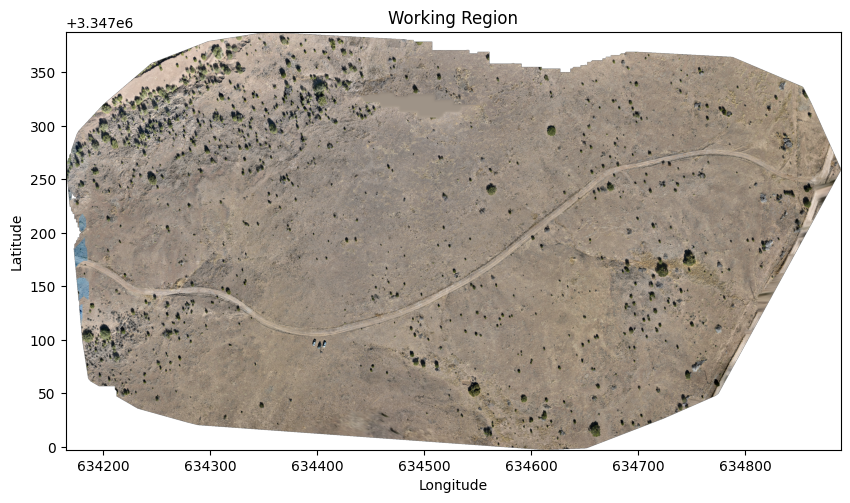

Image dimensions: (1768, 3280, 4)


In [2]:
from plant_search.load_image import load_image, plot_image, plot_geotiff

ds = 4 # downscale ratio

image, transform, bounds, image_crs = load_image(file_path)

# We have a georeferenced image
if image is not None and transform and bounds:
    original_image_shape = image.shape
    image = image[::ds, ::ds]
    # Calculate extent in geographic coordinates
    image_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    plot_geotiff(image, transform, bounds, "Working Region")

# We have image, but not georeferenced
elif image is not None and bounds:
    original_image_shape = image.shape
    height, width = image.shape[:2]
    image_extent = (0, width, 0, height)
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Image dimensions: {image.shape}")

## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [3]:
region_crs = 32613 # Use this everywhere for consistency

simplification_tolerance = 5

# Convert target area to square meters
target_area_acres = 0.5
# target_area_acres = 5

max_iterations = 15

Reached maximum iterations without full convergence.


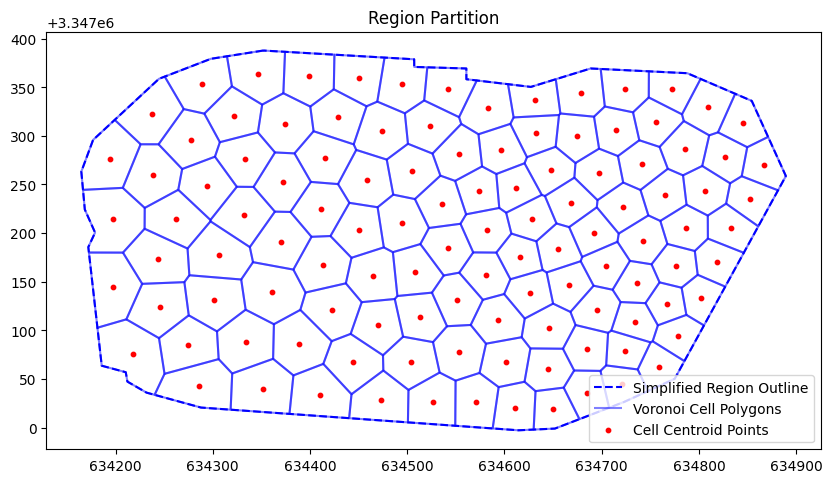

In [4]:
from plant_search.region_partition import (
    extract_region_contour,
    simplify_polygon,
    generate_voronoi_partition,
    centroidal_voronoi_tessellation,
)
import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=region_crs)  # Example: UTM Zone 14N
simplified_polygon = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)

target_area_sqm = target_area_acres * 4046.86
num_points = int(simplified_polygon.area / target_area_sqm)

# voronoi_gdf, points_gdf = generate_voronoi_partition(simplified_polygon, num_points)
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_points, max_iterations)


fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cell Polygons")
cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroid Points")

plt.legend()
plt.title("Region Partition")
plt.show()

## Macro Planning

Since we have divided our working region into smaller, more manageable portions, we can now plan our approach. We will use our cells to help measure area completion and divide work areas more efficiently. 

This section is concerned with:
- clustering of cells into trips
- prioritization of cells
- global trip efficiency
    - A.K.A. Multi-Trip Routing Problem (MTRP)
- Completion efficiency

Our planning inputs:
- cells and centroids
- base station location
    - where drones launch and land
- drone battery range
- target density per cell

In [5]:
from shapely.geometry import Point
import geopandas as gpd

# Cells
# points_gdf

# Base station location
base_station_coords = (634500,3347200)
base_station_gdf = gpd.GeoDataFrame(
    [{'geometry': Point(base_station_coords)}],
    crs=region_crs
)

# Drone battery range
trip_range = 500 # meters

# Cell densities


num_cells: 113
num_vehicles: 14
Objective Value: 7233
Max allowed distance: 800

Vehicle Details:

Vehicle 0:
	Route for vehicle 0:
	   113 ->  74 ->  86 ->  93 ->  102 ->  108 ->  105 ->  103 ->  97 ->  94 ->  84 ->  80 ->  65 ->  51 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 753

Vehicle 1:
	Route for vehicle 1:
	   113 ->  72 ->  81 ->  89 ->  98 ->  107 ->  112 ->  110 ->  111 ->  101 ->  91 ->  82 ->  62 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 792

Vehicle 2:
	Route for vehicle 2:
	   113 ->  66 ->  76 ->  85 ->  92 ->  100 ->  104 ->  109 ->  106 ->  95 ->  58 ->  77 ->  68 ->  57 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 799

Vehicle 3:
	Route for vehicle 3:
	   113 ->  53 ->  54 ->  59 ->  78 ->  90 ->  99 ->  67 ->  61 ->  48 ->  52 ->  47 -> 113
	Cumulative Distance: 800
	Slack: 0
	Route Distance: 689

Vehicle 4:
	Route for vehicle 4:
	   113 ->  34 ->  18 ->  8 ->  3 ->  1 ->  2 ->  13 ->  23 -> 113
	Cumulative Distance:

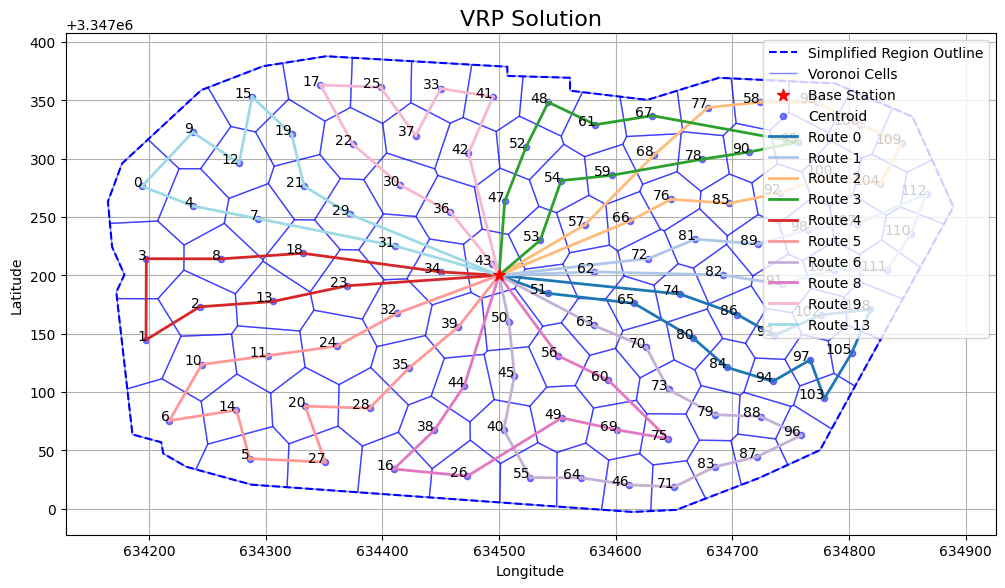

In [6]:
from macro_planning.trip_routing import (
    create_distance_matrix,
    setup_distance_dimension,
    solve_basic_vrp,
)
from macro_planning.visualize_routing import plot_vrp_solution

# Input data

# Create a distance matrix (including intra-workload cost)
distance_matrix = create_distance_matrix(cell_gdf, base_station_gdf)
max_distance = 800  # Max distance per trip
num_cells = len(distance_matrix)-1
# num_vehicles = math.ceil(math.sqrt(num_cells)) + 1
num_vehicles = 14

print(f"num_cells: {num_cells}")
print(f"num_vehicles: {num_vehicles}")

data = {
    "core": {
        "distance_matrix": distance_matrix,
        "num_vehicles": num_vehicles,
        "depot_index": num_cells,
        "max_distance": max_distance,
        "distance_slack": 20,
        "distance_slack_penalty": 10_000,
        "slack_routes": 5
    }
}

print_routes = True
routes = solve_basic_vrp(data, print_routes)

# If solved, plot solution
plot_vrp_solution(cell_gdf, distance_matrix, simplified_polygon, base_station_gdf, routes)


In [ ]:
from plant_search.image_preprocess import (
    generate_target_mask,
    correct_binary_mask,
    identify_targets,
)
import rasterio

# binary_mask = generate_target_mask(image) # Generate

# Load mask the easy way
binary_mask_path = "../outputs/region_binary_mask.tif"
with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    bin_transform = src.transform  # Get the affine transform
    bin_crs = src.crs  # Get the CRS

full_binary_mask = correct_binary_mask(binary_mask, original_image_shape)
targets_gdf = identify_targets(full_binary_mask, transform)


del full_binary_mask # Gimme back my RAM
print(f"Number of targets (detected plants): {len(targets_gdf)}")

In [7]:
# # Instead of re-computing, save to image
# binary_mask_scaled = (binary_mask * 255).astype("uint8")

# with rasterio.open(file_path) as src:
#     image_region_crs = src.crs

# # Save the georeferenced binary mask with the correct scaling
# with rasterio.open(
#     "../outputs/region_binary_mask.tif",
#     "w",
#     driver="GTiff",
#     height=binary_mask.shape[0],
#     width=binary_mask.shape[1],
#     count=1,
#     dtype="uint8",
#     crs=image_region_crs,
#     transform=transform,
# ) as dst:
#     dst.write(binary_mask_scaled, 1)

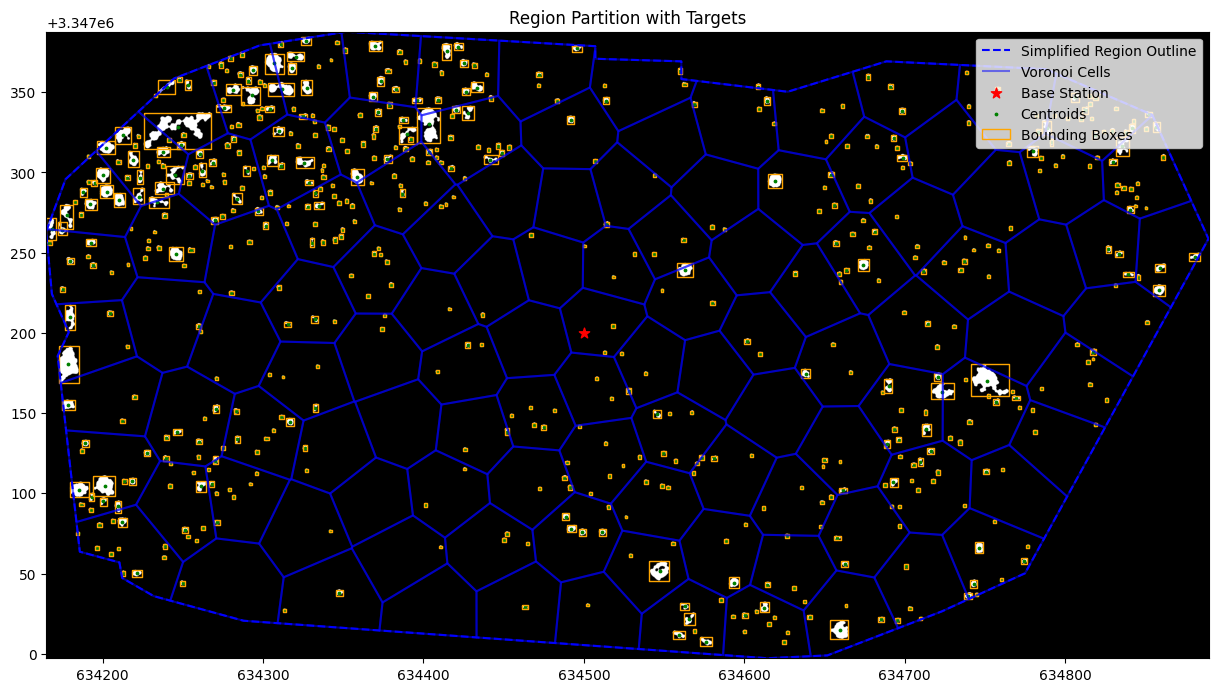

In [ ]:
import matplotlib.patches as mpatches

# Display identified targets
fig, ax = plt.subplots(figsize=(15, 15))
# ax.imshow(image, extent=image_extent, alpha=0.8) # Display original image
ax.imshow(binary_mask, extent=image_extent, cmap='gray') # Show targets binary mask

# Region outline, cells, centroids
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cells") # Region cells
# cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroids")
base_station_gdf.plot(ax=ax, color='red', markersize=60, marker='*', label='Base Station')

targets_gdf.plot(ax=ax, color='green', markersize=3, label='Centroids') # Plot targets centroids
targets_gdf.set_geometry('bounding_box').plot(ax=ax, edgecolor='orange', facecolor='none', linewidth=1.0) # Plot targets bounding boxes

# Fix legend for bounding boxes
handles, labels = ax.get_legend_handles_labels()
bounding_box_patch = mpatches.Patch(edgecolor='orange', facecolor='none', label='Bounding Boxes') # Add a custom handle for the bounding boxes
handles.append(bounding_box_patch)
labels.append('Bounding Boxes')

ax.legend(handles, labels, loc='upper right')
# plt.legend()
plt.title("Region Partition with Targets")
plt.show()

### Calculate Cell Densities

First-pass system to determine:
- Number of targets in each cell
- Distance to traverse all targets in each cell

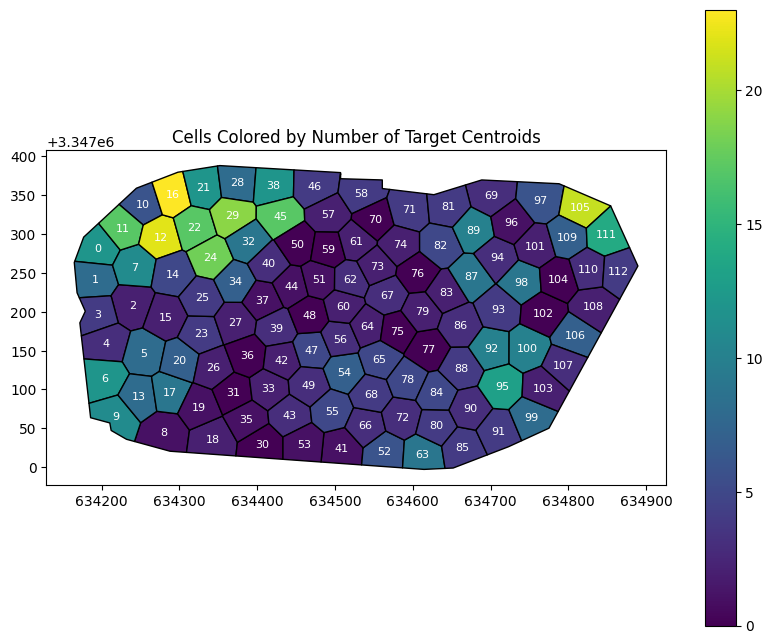

In [ ]:
from plant_search.macro_planning import (
    calculate_cell_workloads,
    plot_cells_with_targets,
    plot_cells_ids,
)


calculate_cell_workloads(cell_gdf, targets_gdf) # In-place updates

# Ensure base station is a valid Point geometry

# Compute distance from each cell centroid to the base station
base_station_point = base_station_gdf.geometry.iloc[0]
cell_gdf['home_distance'] = cell_gdf['cell_centroid'].distance(base_station_point)
cell_gdf['total_workload'] = cell_gdf['intra_workload'] + (2 * cell_gdf['home_distance'])

# Visualize cell workloads
# plot_cells_with_targets(cell_gdf)
plot_cells_ids(cell_gdf)

# targets_gdf
# joined
# cell_gdf

### OR-Tools Trip Planning

This is a complete PIA to understand, but I am relatively confident this constraint solver is exactly what we need.

In [25]:
def evaluate_trip_cost(trip, distance_matrix):
    """
    Evaluates the total cost of a trip.

    Args:
        trip (list): List of node indices representing the trip.
        distance_matrix (np.ndarray): The distance matrix for the problem.

    Returns:
        float: Total cost of the trip.
    """
    if len(trip) < 2:
        return 0  # No cost for empty or single-node trips

    total_cost = 0
    for i in range(len(trip) - 1):
        from_node = trip[i]
        to_node = trip[i + 1]
        total_cost += distance_matrix[from_node][to_node]

    return total_cost


def evaluate_all_trips(trips, distance_matrix):
    """
    Evaluates the total cost of all trips.

    Args:
        trips (list of lists): List of trips, where each trip is a list of node indices.
        distance_matrix (np.ndarray): The distance matrix for the problem.

    Returns:
        dict: Dictionary with trip costs and total cost.
    """
    trip_costs = []
    total_cost = 0

    for trip in trips:
        trip_cost = evaluate_trip_cost(trip, distance_matrix)
        trip_costs.append(trip_cost)
        total_cost += trip_cost

    return {
        "trip_costs": trip_costs,
        "total_cost": total_cost
    }

# costs = evaluate_all_trips(trips, d_matrix)

# print("Trip Costs:", costs["trip_costs"])
# print("Total Cost:", costs["total_cost"])

### Data Relations

Finally, after much computation, we can now begin to treat our GDFs as database tables and relate them. 

First, we attempt to associate each target with a cell.

## Micro Planning

Perform image analysis on each smaller section of our greater region.